# SpecWorth — Explainable Laptop Valuation & Uncertainty Estimation

SpecWorth is an end-to-end machine learning system for laptop price estimation and fair-price analysis. It transforms raw CPU, processor, GPU, RAM, storage, display, and operating-system specifications into structured model features and uses a tuned XGBoost regression model to estimate laptop prices.

Beyond point prediction, the project includes automated preprocessing and feature selection, cross-validated model comparison, hyperparameter tuning, segment-wise error analysis, local perturbation-based explanations, and split conformal calibration for prediction intervals. The resulting models and application artifacts are serialized and consumed by a Streamlit interface for custom laptop valuation and deal analysis.

The training notebook is the complete training pipeline and is intended to be executed top to bottom.

**Dataset**: [Kaggle — Laptop Price Prediction Dataset](https://www.kaggle.com/datasets/jacksondivakarr/laptop-price-prediction-dataset)  
**Dataset size**: 893 Indian-market laptop listings

## 1. Setup

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from feature_engineering import cpu_features, processor_features, gpu_features, os_family, calculate_ppi

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 2. Load & Initial Clean

In [2]:
df = pd.read_csv("data/laptops_raw.csv")
print(df.shape)
df.sample(5)

(893, 18)


,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
593,620,701,Lenovo,IdeaPad Gaming 3 15IHU6 82K101PCIN Laptop,47990,65.000000,11th Gen Intel Core i5 11320H,"Quad Core, 8 Threads",8GB,DDR4,512GB,SSD,4GB NVIDIA GeForce GTX 2050,15.6,1920.0,1080.0,Windows 11 OS,1
557,582,662,Lenovo,IdeaPad Slim 5 82XD005RIN Laptop,71990,69.323529,13th Gen Intel Core i5 13420H,"Octa Core (4P + 4E), 12 Threads",16GB,LPDDR5,512GB,SSD,Integrated Intel Iris Xe Graphics,14.0,1920.0,1200.0,Windows 11 OS,2
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
810,848,935,Acer,One 14 2023 Z8-415 ‎Laptop,39990,69.323529,11th Gen Intel Core i5 1135G7,"Quad Core, 8 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
838,876,964,MSI,Modern 14 C12M-444IN Laptop,36990,62.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",16GB,DDR4,512GB,SSD,Intel Integrated UHD,14.0,1920.0,1080.0,Windows 11 OS,1


In [3]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"{col} → {df[col].nunique()} unique values")
    print(df[col].unique())


Unnamed: 0.1 → 893 unique values
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 109 110
 111 112 113 114 116 117 118 119 120 121 122 123 124 125 126 127 128 129
 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147
 148 149 150 152 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203
 204 205 206 207 208 209 210 211 213 214 215 216 217 219 220 221 223 224
 225 228 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 248 249 250 

In [4]:
df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], inplace=True)

In [5]:
df["Ram"] = df["Ram"].str.replace("GB", "", regex=False).astype(int)

df["ROM"] = (
    df["ROM"].replace({"1TB": "1024", "2TB": "2048"})
    .str.replace("GB", "", regex=False).astype(int)
)

df["Ram_type"] = df["Ram_type"].replace({
    "LPDDR4x": "LPDDR4X", "LPDDR5x": "LPDDR5X", "DDR4-": "DDR4", "DDR": "Unknown"
})

df["OS"] = df["OS"].str.replace(r"\s+", " ", regex=True).str.strip()
df["OS"] = df["OS"].replace({
    "Windows 11 OS": "Windows 11", "Windows 10 OS": "Windows 10", "Windows OS": "Windows",
    "Mac OS": "macOS", "Mac Catalina OS": "macOS", "Mac High Sierra OS": "macOS", "Mac 10.15.3 OS": "macOS",
    "DOS OS": "DOS", "DOS 3.0 OS": "DOS",
    "Chrome OS": "Chrome OS", "Ubuntu OS": "Ubuntu", "Android 11 OS": "Android",
})


In [6]:
df_clean = df.copy()   # kept for the app's "Quick Pick" catalog browser
df.isnull().sum()

brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 3. EDA

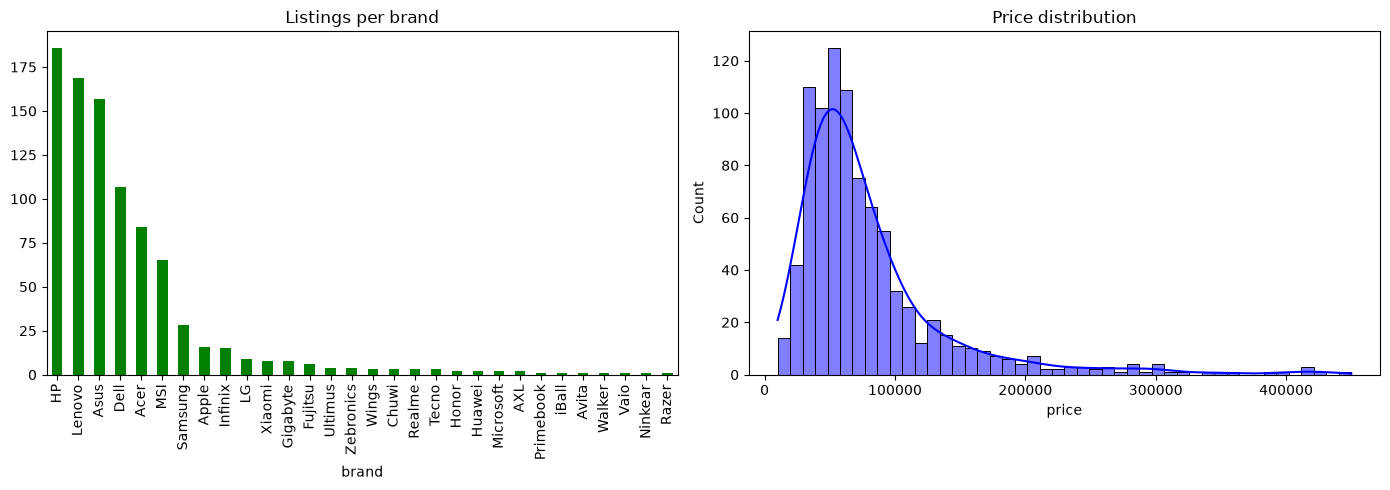

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["brand"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="green",
    title="Listings per brand"
)

sns.histplot(
    df["price"],
    kde=True,
    ax=axes[1],
    color="blue"
)

axes[1].set_title("Price distribution")

plt.tight_layout()
plt.show()

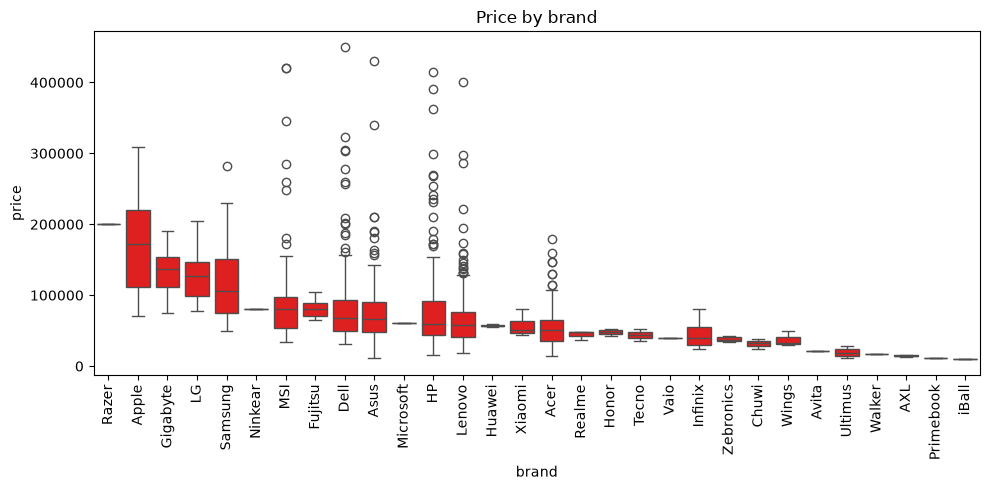

In [9]:
plt.figure(figsize=(10, 5))
order = df.groupby("brand")["price"].median().sort_values(ascending=False).index
sns.boxplot(
    x="brand",
    y="price",
    data=df,
    order=order,
    color="red"
)
plt.xticks(rotation=90)
plt.title("Price by brand")
plt.tight_layout()
plt.show()

## 4. Feature engineering

In [10]:
df["ppi"] = df.apply(lambda r: calculate_ppi(r["display_size"], f"{int(r['resolution_width'])}x{int(r['resolution_height'])}"), axis=1)
df.drop(columns=["resolution_width", "resolution_height", "display_size"], inplace=True)

cpu_cols = ["Total_Cores", "Threads", "P_Cores", "E_Cores", "Hybrid_CPU", "Core_Type", "Hyperthreading", "Threads_per_Core"]
df[cpu_cols] = df["CPU"].apply(lambda t: pd.Series(cpu_features(t)))
df.drop(columns=["CPU"], inplace=True)

proc_cols = ["Processor_Brand", "Processor_Family", "Generation"]
df[proc_cols] = df["processor"].apply(lambda t: pd.Series(processor_features(t)))
df.drop(columns=["processor"], inplace=True)

gpu_cols = ["GPU_Brand", "GPU_Family", "VRAM_GB", "Integrated_GPU", "Dedicated_GPU"]
df[gpu_cols] = df["GPU"].apply(lambda t: pd.Series(gpu_features(t)))
df.drop(columns=["GPU"], inplace=True)

df["SSD"] = (df["ROM_type"] == "SSD").astype("int8")
df.drop(columns=["ROM_type"], inplace=True)

df["OS_Family"] = df["OS"].apply(os_family)
df.drop(columns=["OS"], inplace=True)

binary_cols = ["Hybrid_CPU", "Hyperthreading", "Integrated_GPU", "Dedicated_GPU", "SSD"]
df[binary_cols] = df[binary_cols].astype("int8")
df["Threads"] = df["Threads"].astype("Int64")
df["Generation"] = df["Generation"].astype("Int64")

# Dropped, not used as model features:
# name: free-text product name, near-unique per row, not usable as a category
# spec_rating: composite score a real user can't supply 
df.drop(columns=["name", "spec_rating"], inplace=True)

df["price_segment"] = pd.qcut(df["price"], q=3, labels=["Budget", "Mid-range", "Premium"])
print(df.shape)
df.head()

(893, 26)


,brand,price,Ram,Ram_type,ROM,warranty,ppi,Total_Cores,Threads,P_Cores,E_Cores,Hybrid_CPU,Core_Type,Hyperthreading,Threads_per_Core,Processor_Brand,Processor_Family,Generation,GPU_Brand,GPU_Family,VRAM_GB,Integrated_GPU,Dedicated_GPU,SSD,OS_Family,price_segment
0,HP,49900,8,DDR4,512,1,141.211998,6,12,0,0,0,Hexa,1,2.000000,AMD,Ryzen 5,5,AMD,Radeon,4,0,1,1,Windows,Budget
1,HP,39900,8,DDR4,512,1,141.211998,6,8,2,4,1,Hexa,1,1.333333,Intel,Core i3,12,Intel,UHD,0,1,0,1,Windows,Budget
2,Acer,26990,8,DDR4,512,1,157.350512,2,4,0,0,0,Dual,1,2.000000,Intel,Core i3,11,Intel,Iris Xe,0,1,0,1,Windows,Budget
3,Lenovo,59729,16,LPDDR5,512,1,188.679623,12,16,4,8,1,Numeric,1,1.333333,Intel,Core i5,12,Intel,Iris Xe,0,1,0,1,Windows,Mid-range
4,Apple,69990,8,DDR4,256,1,226.983005,8,<NA>,4,4,1,Octa,0,NaN,Apple,Apple M1,<NA>,Apple,Other,0,1,0,1,macOS,Mid-range


### PPI formula
`PPI = sqrt(width² + height²) / screen_size_inches` -- diagonal resolution in pixels, divided by diagonal screen size in inches. One number that captures screen sharpness better than width/height/size as three separate features.

## 5. Train / test split

In [11]:
X = df.drop(columns=["price", "price_segment"])
y = df["price"]
segments = df["price_segment"]

X_train, X_test, y_train, y_test, seg_train, seg_test = train_test_split(
    X, y, segments, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Train: (714, 24) Test: (179, 24)


## 6. Preprocessing + model comparison

Feature selection (`SelectFromModel`) is a **pipeline step**, refit inside every CV fold --
not computed once on the full training set beforehand. That avoids a subtle leakage: if
feature selection sees the full training target before cross-validation splits happen, the
reported CV score is mildly optimistic.

In [12]:
num_cols = ["Ram", "ROM", "warranty", "ppi", "Total_Cores", "Threads",
            "P_Cores", "E_Cores", "Threads_per_Core", "Generation", "VRAM_GB"]
cat_cols = ["brand", "Ram_type", "Core_Type", "Processor_Brand", "Processor_Family",
            "GPU_Brand", "GPU_Family", "OS_Family"]
bin_cols = binary_cols

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
    ("bin", "passthrough", bin_cols),
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(estimator):
    return Pipeline([
        ("prep", preprocessor),
        ("select", SelectFromModel(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), threshold="median")),
        ("model", estimator),
    ])

candidates = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
for name, est in candidates.items():
    pipe = make_pipeline(est)
    scores = cross_validate(
        pipe, X_train, y_train_log, cv=cv,
        scoring={"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"},
        n_jobs=-1,
    )
    results.append({
        "Model": name,
        "CV R2": round(scores["test_r2"].mean(), 4),
        "CV MAE (log)": round(-scores["test_mae"].mean(), 4),
        "CV RMSE (log)": round(-scores["test_rmse"].mean(), 4),
    })

cv_results = pd.DataFrame(results).sort_values("CV R2", ascending=False)
cv_results

,Model,CV R2,CV MAE (log),CV RMSE (log)
3,XGBoost,0.8771,0.1419,0.2106
2,Random Forest,0.8711,0.1449,0.2160
0,Linear Regression,0.8550,0.1566,0.2284
1,Decision Tree,0.7886,0.1765,0.2753


## 7. Hyperparameter tuning

In [13]:
tuned_pipe = make_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))

param_grid = {
    "model__n_estimators": [200,275, 300],
    "model__learning_rate": [0.05,0.075, 0.1],
    "model__max_depth": [4,5, 6],
    "model__min_child_weight": [1,3, 5],
}

grid_search = GridSearchCV(estimator=tuned_pipe, param_grid=param_grid, scoring="r2", cv=3, n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train_log)

print("Best CV R2:", round(grid_search.best_score_, 4))
print("Best params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best CV R2: 0.8614
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 200}


## 8. Final model and conformal calibration
The deployed model is fit on 80% of the training set; the held-out 20% is used
only to calibrate the conformal quantile. Point estimate and interval therefore
come from the same model, which is what makes the coverage figure meaningful.

In [14]:
# ---- Final (deployed) model: fit / calibrate split ----------------------
# Split conformal needs a calibration set the model never saw, so the model
# we deploy is fit on 80% of X_train (64% of all data) and calibrated on the
# remaining 20%. Hyperparameters are reused from the CV search above.
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
)
y_fit_log = np.log1p(y_fit)
y_cal_log = np.log1p(y_cal)

final_model = make_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))
final_model.set_params(**grid_search.best_params_)
final_model.fit(X_fit, y_fit_log)

print("Fit on", X_fit.shape[0], "rows | calibrating on", X_cal.shape[0], "rows")

Fit on 571 rows | calibrating on 143 rows


In [15]:
# ---- Split conformal calibration ---------------------------------------
cal_residuals = np.abs(y_cal_log - final_model.predict(X_cal))

alpha = 0.20
n_cal = len(cal_residuals)
k = int(np.ceil((n_cal + 1) * (1 - alpha)))
q_conformal = float(np.sort(cal_residuals)[k - 1])

print(f"n_cal = {n_cal} | q_conformal (log scale) = {q_conformal:.4f}")

n_cal = 143 | q_conformal (log scale) = 0.2264


## 9. Test-set evaluation
Point accuracy and interval coverage, both measured on the untouched test set.

In [16]:
# ---- Test-set evaluation: point estimate AND interval, same model ------
test_pred_log = final_model.predict(X_test)

y_pred = np.expm1(test_pred_log)
y_true = y_test.to_numpy(dtype=float)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

conformal_lower = np.expm1(test_pred_log - q_conformal)
conformal_upper = np.expm1(test_pred_log + q_conformal)
conformal_coverage = float(
    np.mean((y_true >= conformal_lower) & (y_true <= conformal_upper)) * 100
)

print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"80% interval coverage : {conformal_coverage:.1f}%  (target 80%, n_cal={n_cal})")

MAE  : ₹9,842.09
RMSE : ₹15,883.78
R²   : 0.9264
80% interval coverage : 86.6%  (target 80%, n_cal=143)


## 10. Naive baseline

In [17]:
baseline_pred = np.full(len(y_true), y_train.mean())

print("Naive baseline (predict mean training price)")
print(f"  MAE  : ₹{mean_absolute_error(y_true, baseline_pred):,.2f}")
print(f"  RMSE : ₹{np.sqrt(mean_squared_error(y_true, baseline_pred)):,.2f}")
print(f"  R²   : {r2_score(y_true, baseline_pred):.4f}")
print(f"\nDeployed XGBoost\n  MAE  : ₹{mae:,.2f}\n  RMSE : ₹{rmse:,.2f}\n  R²   : {r2:.4f}")

Naive baseline (predict mean training price)
  MAE  : ₹40,045.58
  RMSE : ₹58,617.23
  R²   : -0.0027

Deployed XGBoost
  MAE  : ₹9,842.09
  RMSE : ₹15,883.78
  R²   : 0.9264


## 11. Segment-aware error report
One global R² hides where the model struggles. Note that R² is *not*
comparable across these segments: they are price terciles, so the middle band
has the narrowest price range and hence the smallest total sum of squares.
MAPE is the metric to read across segments.

In [18]:
seg_report = []
for seg in ["Budget", "Mid-range", "Premium"]:
    mask = (seg_test == seg).to_numpy()
    seg_report.append({
        "Segment": seg,
        "n": int(mask.sum()),
        "MAE": round(float(mean_absolute_error(y_true[mask], y_pred[mask])), 2),
        "R2": round(float(r2_score(y_true[mask], y_pred[mask])), 3),
        "MAPE %": round(float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100), 2),
    })

seg_report_df = pd.DataFrame(seg_report)
# R² is not comparable across these segments: they are price terciles, so the
# middle band has the narrowest price range and hence the smallest SS_total.
# MAPE is the metric to read across segments.
seg_report_df

,Segment,n,MAE,R2,MAPE %
0,Budget,63,5087.83,0.355,14.17
1,Mid-range,65,6618.87,-0.061,10.58
2,Premium,51,19823.01,0.853,13.51


## 12. Feature importance

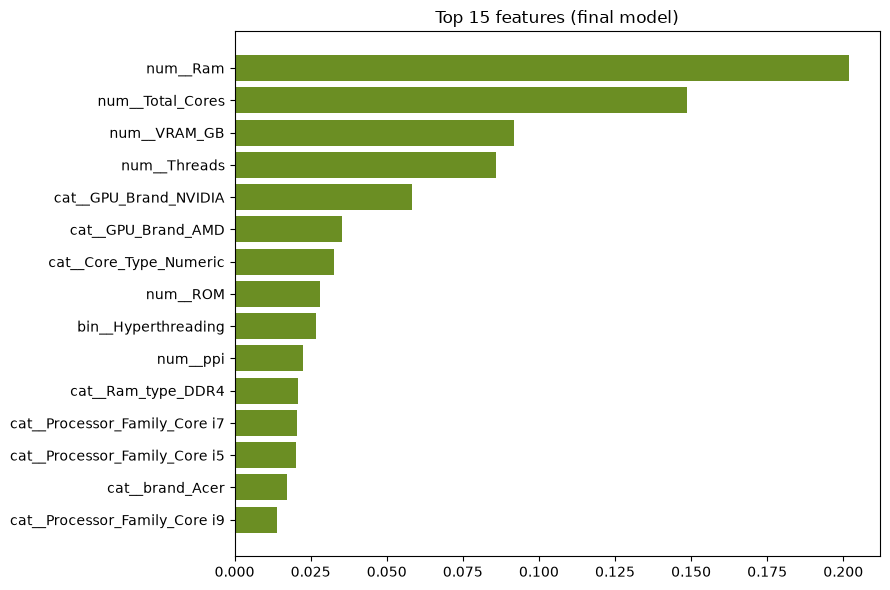

In [19]:
selected_mask = final_model.named_steps["select"].get_support()
all_feature_names = final_model.named_steps["prep"].get_feature_names_out()
selected_names = all_feature_names[selected_mask]

importances = final_model.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": selected_names, "importance": importances}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],color="olivedrab")
plt.title("Top 15 features (final model)")
plt.tight_layout()
plt.show()

## 13. Residual analysis

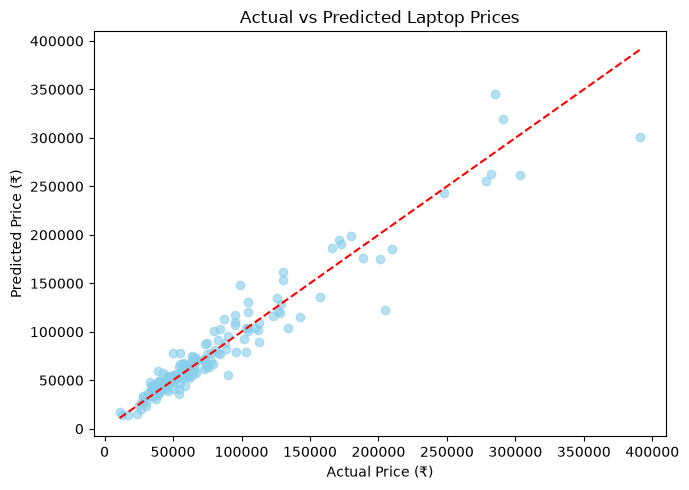

In [20]:
plt.figure(figsize=(7, 5))

plt.scatter(y_true, y_pred, alpha=0.6, color="skyblue")

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Laptop Prices")

plt.tight_layout()
plt.show()

In [21]:
residuals = y_true - y_pred

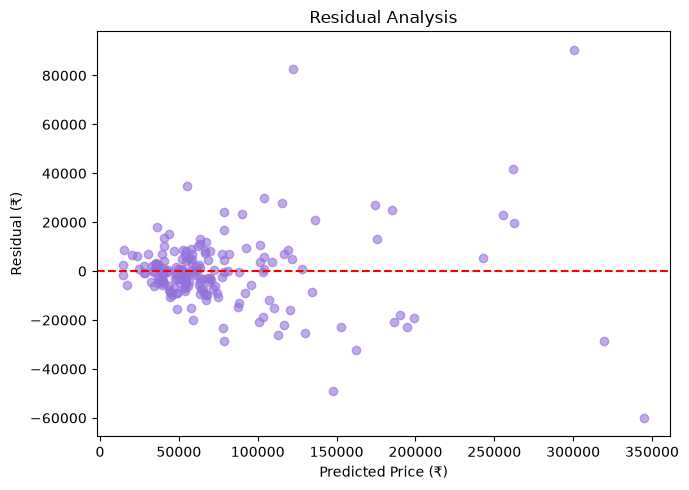

In [22]:
plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, alpha=0.6, color="mediumpurple")

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Price (₹)")
plt.ylabel("Residual (₹)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## 14. Save deployment artifacts

In [23]:
import os
os.makedirs("models", exist_ok=True)

# One deployed model produces both the point estimate and the interval.
joblib.dump(final_model, "models/price_model.pkl")
joblib.dump(q_conformal, "models/conformal_quantile.pkl")
joblib.dump(list(X.columns), "models/model_input_columns.pkl")
joblib.dump(df_clean, "models/lookup_df.pkl")

metrics = {
    "n_listings": int(len(df)),
    "n_fit": int(len(X_fit)), "n_cal": int(n_cal), "n_test": int(len(X_test)),
    "test_mae": round(float(mae), 2),
    "test_rmse": round(float(rmse), 2),
    "test_r2": round(float(r2), 4),
    "conformal_alpha": alpha,
    "conformal_quantile_log": round(float(q_conformal), 4),
    "conformal_interval_coverage_pct": round(float(conformal_coverage), 1),
    "best_params": {k.replace("model__", ""): v for k, v in grid_search.best_params_.items()},
    "cv_leaderboard": cv_results.to_dict(orient="records"),
    "segment_report": seg_report_df.to_dict(orient="records"),
}
with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

dropdowns = {
    "brand": sorted(df_clean["brand"].unique().tolist()),
    "processor": sorted(df_clean["processor"].unique().tolist()),
    "cpu": sorted(df_clean["CPU"].unique().tolist()),
    "gpu": sorted(df_clean["GPU"].unique().tolist()),
    "ram_type": sorted(df_clean["Ram_type"].unique().tolist()),
    "os": sorted(df_clean["OS"].unique().tolist()),
}
joblib.dump(dropdowns, "models/dropdowns.pkl")

# Reference row for the explanation panel, drawn from X_fit -- exactly the
# data the deployed model was trained on.
reference = {}
for col in num_cols:
    reference[col] = float(X_fit[col].median())
for col in cat_cols:
    reference[col] = X_fit[col].mode().iloc[0]
for col in bin_cols:
    reference[col] = int(X_fit[col].mode().iloc[0])
joblib.dump(reference, "models/feature_reference.pkl")

print("Artifacts saved to models/")

Artifacts saved to models/
